# Climate Indices with Earthkit & Xclim

This notebook demonstrates how to compute and visualize **climate indices** from CMIP6 datasets using the `earthkit-climate` and `xclim` packages.

We'll use:
- **Precipitation-based indices**:
  - *SDII*: Simple Daily Intensity Index (average precipitation on wet days)
  - *CWD*: Consecutive Wet Days (max number of wet days in a row)

- **Temperature-based indices**:
  - *DTR*: Daily Temperature Range (Tmax - Tmin)
  - *WSDI*: Warm Spell Duration Index (≥6 consecutive days above 90th percentile)
  - *HDD*: Heating Degree Days (based on temperature below threshold)

We’ll load **ACCESS-CM2 CMIP6 data** for both *historical* and *SSP585* scenarios.


In [4]:
import earthkit.data as ekd
import xarray as xr
import matplotlib.pyplot as plt
import xclim
import earthkit.plots
import cartopy.crs as ccrs

from earthkit.climate.indicators.precipitation import (
    daily_precipitation_intensity,
    maximum_consecutive_wet_days,
)
from earthkit.climate.indicators.temperature import (
    daily_temperature_range,
    warm_spell_duration_index,
    heating_degree_days,
)

plt.rcParams["figure.figsize"] = (8, 5)


## Loading CMIP6 data

We’ll use *daily gridded data* from the ACCESS-CM2 model for precipitation (`pr`), maximum (`tasmax`) and minimum (`tasmin`) temperature, for both historical and SSP585 future scenarios.


In [2]:
# Load precipitation
pr_hist = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/pr_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_historical.nc",
)
pr_ssp585 = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/pr_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_ssp585.nc",
)

# Load temperature
tasmin_hist = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmin_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_historical.nc",
)
tasmin_ssp585 = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmin_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_ssp585.nc",
)

tasmax_hist = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmax_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_historical.nc",
)
tasmax_ssp585 = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmax_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_ssp585.nc",
)


## Inspect and visualize the raw data

Before computing indices, let’s plot a few example grids to see how the raw variables look.


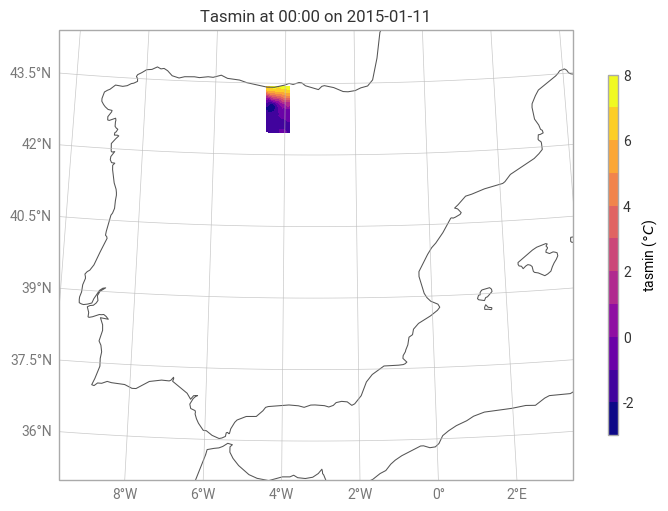

In [16]:
chart = earthkit.plots.Map(domain="Spain")
chart.quickplot(tasmin_ssp585.to_xarray().isel(time=10), units="celsius")

chart.legend(location="right")

chart.coastlines()

chart.title()
chart.gridlines()

chart.show()

In [14]:
tasmin_ssp585.to_xarray()


<xarray.Dataset> Size: 35MB
Dimensions:  (time: 31411, lat: 20, lon: 14)
Coordinates:
  * time     (time) datetime64[ns] 251kB 2015-01-01 2015-01-02 ... 2100-12-31
  * lat      (lat) float64 160B 42.47 42.52 42.57 42.62 ... 43.32 43.37 43.42
  * lon      (lon) float64 112B -4.525 -4.475 -4.425 ... -3.975 -3.925 -3.875
    height   float64 8B ...
Data variables:
    tasmin   (time, lat, lon) float32 35MB dask.array<chunksize=(15706, 10, 7), meta=np.ndarray>
Attributes:
    model:         ACCESS-CM2_r1i1p1f1_deepESD
    scenario:      ssp585
    project_name:  cmip6
    project_type:  projections